# Lab 2 — Precision Recruiting with Recommender Systems

**Mission:** Limited recruiter time means we cannot visit every school. Build a transparent system that answers:

1. **WHERE should we focus?** Rank schools by downstream value and operational feasibility.
2. **WHAT should we try there?** Recommend an engagement using patterns from behaviorally similar schools.

You will deliberately begin with the wrong objective, watch the ranking change, and then infer a promising action Jefferson High has never tried.

**Estimated time:** 75 minutes (Lab A: 30; Lab B: 45)

> **Completed instructor version.** Exercise values and functions are filled in, self-checks are executed, and explanations follow each solution. 

> **Use your coding assistant as a teammate.** Give it the current cell, the self-check output, and the goal. Ask it to explain the smallest useful change rather than rewriting the notebook.

Suggested prompt:

> I am working in a classroom Jupyter notebook. Explain what this self-check is testing, then suggest the smallest edit to the marked variables. Do not change the data or the test.

In [1]:
from IPython.display import display, Markdown

def check(name, condition, hint=""):
    try:
        passed = bool(condition)
    except Exception as exc:
        passed = False
        hint = f"{hint} ({type(exc).__name__}: {exc})"
    icon = "✅" if passed else "❌"
    print(f"{icon} {name}")
    if not passed and hint:
        print(f"   Hint: {hint}")
    return passed

def mission_header(text):
    display(Markdown(f"> **Mission checkpoint:** {text}"))

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
pd.set_option("display.max_columns", 30)
pd.options.display.float_format = "{:,.3f}".format

## Prepared artifacts from Lab 1

Lab 2 uses validated CSV artifacts produced by the Lab 1 pipeline. Prepared copies are supplied so this lab remains runnable even if a team has not completed Lab 1. All records are fictional classroom data; protected characteristics are not used.

In [3]:
schools = pd.read_csv("https://usard-demo.netlify.app/data/school_summary.csv")
engagements = pd.read_csv("https://usard-demo.netlify.app/data/clean_recruiting_events.csv", parse_dates=["event_date"])

print(f"Loaded {len(schools)} school summaries and {len(engagements)} clean events.")
schools.head(8)

Loaded 36 school summaries and 459 clean events.


,school_id,school_name,historical_events,recruiter_hours,contacts,appointments,qualified,contracts,access_score,distance_miles
0,S001,Lincoln High,23,147,1046,495,143,48,0.900,8
1,S002,Jefferson High,19,117,655,252,145,64,0.920,12
2,S003,Washington High,17,105,672,226,126,60,0.720,18
3,S004,Roosevelt High,12,83,469,152,81,26,0.950,6
4,S005,North County Tech,14,95,507,173,98,48,0.800,22
5,S006,Lakeside Academy,12,82,404,151,84,27,0.940,32
6,S007,Madison High,19,118,737,240,139,49,0.770,35
7,S008,Franklin High,14,91,479,148,80,23,0.710,47


# Lab A — WHERE should we focus?

## A1. Rank by activity

If appointments are the goal, Lincoln appears to win. Pause before running the next cell: is appointment volume the outcome USARD actually wants to optimize?

In [4]:
appointment_ranking = schools.nlargest(5, "appointments")[["school_name", "appointments", "qualified", "contracts"]]
appointment_ranking

,school_name,appointments,qualified,contracts
0,Lincoln High,495,143,48
1,Jefferson High,252,145,64
20,Hamilton High,242,129,32
6,Madison High,240,139,49
31,Redstone High,231,128,48


## A2. Look downstream

Complete the four marked column choices. The cell runs even before it is correct; the checks tell you what to fix.

In [5]:
QUALIFIED_NUMERATOR = "qualified"    # downstream qualified applicants
QUALIFIED_DENOMINATOR = "appointments" # appointment opportunities
EFFICIENCY_NUMERATOR = "contracts"     # downstream outcome
EFFICIENCY_DENOMINATOR = "recruiter_hours"

schools["qualified_rate"] = (
    schools[QUALIFIED_NUMERATOR] / schools[QUALIFIED_DENOMINATOR]
)
schools["contracts_per_hour"] = (
    schools[EFFICIENCY_NUMERATOR] / schools[EFFICIENCY_DENOMINATOR]
)

schools.nlargest(5, "contracts_per_hour")[[
    "school_name", "appointments", "qualified", "contracts", "contracts_per_hour"
]]

,school_name,appointments,qualified,contracts,contracts_per_hour
2,Washington High,226,126,60,0.571
1,Jefferson High,252,145,64,0.547
35,Victory High,25,15,7,0.538
4,North County Tech,173,98,48,0.505
8,Central High,102,66,23,0.479


### Solution explanation — downstream measures

`qualified ÷ appointments` measures how often appointments reach qualification. `contracts ÷ recruiter_hours` measures downstream success per constrained resource. These choices deliberately move the objective away from raw activity volume.

In [6]:
check("Qualification rate uses qualified ÷ appointments",
      QUALIFIED_NUMERATOR == "qualified" and QUALIFIED_DENOMINATOR == "appointments",
      "The numerator is the number that made it through qualification.")
check("Efficiency uses contracts ÷ recruiter hours",
      EFFICIENCY_NUMERATOR == "contracts" and EFFICIENCY_DENOMINATOR == "recruiter_hours",
      "We care about downstream success per constrained hour.")
check("Lincoln's appointment volume does not make it the efficiency leader",
      schools.nlargest(1, "appointments").iloc[0]["school_name"] != schools.nlargest(1, "contracts_per_hour").iloc[0]["school_name"],
      "Fix the efficiency numerator first.")

✅ Qualification rate uses qualified ÷ appointments
✅ Efficiency uses contracts ÷ recruiter hours
✅ Lincoln's appointment volume does not make it the efficiency leader


True

## A3. Define an explainable opportunity score

The mission owner chose:

- 60% downstream efficiency
- 25% qualification rate
- 15% school access

Edit the three weights. The algorithm cannot decide the objective for us.

In [7]:
scaler = MinMaxScaler()
features = ["contracts_per_hour", "qualified_rate", "access_score"]
schools[["success_norm", "qualified_norm", "access_norm"]] = scaler.fit_transform(schools[features])

SUCCESS_WEIGHT = .60
QUALIFIED_WEIGHT = .25
ACCESS_WEIGHT = .15

schools["opportunity_score"] = (
    SUCCESS_WEIGHT * schools["success_norm"]
    + QUALIFIED_WEIGHT * schools["qualified_norm"]
    + ACCESS_WEIGHT * schools["access_norm"]
)

### Solution explanation — mission weights

The weights encode a human-defined operational objective: 60% downstream efficiency, 25% qualification rate, and 15% access. Normalization puts unlike measures on a common 0–1 scale before the weighted sum.

In [8]:
check("Weights sum to 1", np.isclose(SUCCESS_WEIGHT + QUALIFIED_WEIGHT + ACCESS_WEIGHT, 1.0))
check("Weights match the mission objective",
      np.allclose([SUCCESS_WEIGHT, QUALIFIED_WEIGHT, ACCESS_WEIGHT], [.60, .25, .15]),
      "Translate 60%, 25%, and 15% into decimals.")

✅ Weights sum to 1
✅ Weights match the mission objective


True

## A4. Filter infeasible or thinly supported options

Scores do not override operations. Set the thresholds to **30 miles** and at least **4 historical events**. Event count is observable evidence volume—not a made-up “data quality” score.

In [9]:
MAX_DISTANCE = 30
MIN_HISTORICAL_EVENTS = 4

eligible = schools.loc[
    schools["distance_miles"].le(MAX_DISTANCE)
    & schools["historical_events"].ge(MIN_HISTORICAL_EVENTS)
].copy()

excluded = schools.loc[~schools.index.isin(eligible.index), [
    "school_name", "distance_miles", "historical_events", "opportunity_score"
]].sort_values("opportunity_score", ascending=False)
display(Markdown("**Excluded options**"))
display(excluded)

**Excluded options**

,school_name,distance_miles,historical_events,opportunity_score
35,Victory High,14,2,0.837
25,Heritage High,39,9,0.750
6,Madison High,35,19,0.702
31,Redstone High,36,18,0.678
5,Lakeside Academy,32,12,0.665
12,Pine Ridge High,46,7,0.622
17,Liberty High,44,8,0.558
22,Jackson High,38,9,0.516
20,Hamilton High,33,19,0.484
27,Mountain View High,34,17,0.474


### Solution explanation — operational constraints

Filtering happens before Top-K selection. Liberty is removed because travel exceeds the current limit; Victory is removed because only two historical events are available. A strong score cannot override feasibility or thin evidence.

In [10]:
check("Distance threshold is operationally correct", MAX_DISTANCE == 30)
check("Evidence threshold is operationally correct", MIN_HISTORICAL_EVENTS == 4)
check("Liberty is excluded for travel", "Liberty High" not in set(eligible["school_name"]))
check("Victory is excluded for insufficient history", "Victory High" not in set(eligible["school_name"]))
check("No arbitrary data-quality metric is used", "data_quality" not in schools.columns)

✅ Distance threshold is operationally correct
✅ Evidence threshold is operationally correct
✅ Liberty is excluded for travel
✅ Victory is excluded for insufficient history
✅ No arbitrary data-quality metric is used


True

## A5. Return Top K

Set `K = 5`. The winning school at the top of this list becomes the target for Lab B.

In [11]:
K = 5
top_schools = eligible.nlargest(K, "opportunity_score").copy()
top_schools[["school_name", "opportunity_score", "contracts_per_hour", "qualified_rate", "access_score"]]

,school_name,opportunity_score,contracts_per_hour,qualified_rate,access_score
1,Jefferson High,0.906,0.547,0.575,0.920
2,Washington High,0.835,0.571,0.558,0.720
8,Central High,0.831,0.479,0.647,0.800
16,Parkview High,0.814,0.443,0.606,0.920
4,North County Tech,0.803,0.505,0.566,0.800


### Solution explanation — Top K

`K = 5` returns a manageable shortlist. Jefferson is the clear winner on the stated weighted objective, so the notebook passes that top-ranked school directly into the action recommender.

✅ Top K returns five schools
✅ Jefferson wins the final school ranking


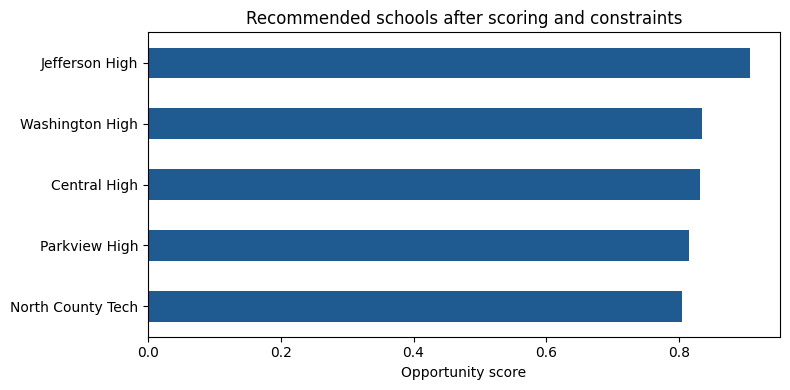

In [12]:
check("Top K returns five schools", K == 5 and len(top_schools) == 5)
check("Jefferson wins the final school ranking", top_schools.iloc[0]["school_name"] == "Jefferson High")

ax = top_schools.sort_values("opportunity_score").plot.barh(
    x="school_name", y="opportunity_score", legend=False, color="#1f5a91", figsize=(8, 4)
)
ax.set(title="Recommended schools after scoring and constraints", xlabel="Opportunity score", ylabel="")
plt.tight_layout()
plt.show()

> **Aha:** A recommender can produce a perfectly correct ranking for the wrong objective. There is no universal “best” school—only a ranking tied to an objective, evidence, and constraints.

# Lab B — WHAT should we do there?

Lab A selected Jefferson High. We now treat schools like “users,” engagement actions like “items,” and historical contracts per recruiter-hour like a “rating” to decide what to try there.

In [13]:
actions = [
    "Cyber Careers Event", "STEM Careers Presentation", "Mechanical Careers Demo",
    "Healthcare Careers Session", "Education Benefits Session", "General Recruiting Table"
]

print(f"The event artifact contains {len(engagements):,} validated engagements.")
engagements.sample(8, random_state=SEED)[[
    "engagement_id", "event_date", "school_name", "action",
    "recruiter_hours", "contracts"
]]

The event artifact contains 459 validated engagements.


,engagement_id,event_date,school_name,action,recruiter_hours,contracts
124,E1474,2025-12-01,Union High,Mechanical Careers Demo,10,3
30,E1340,2025-09-20,Wilson High,General Recruiting Table,5,0
199,E1223,2026-01-24,Cedar Grove High,Healthcare Careers Session,8,2
438,E1338,2026-07-12,Wilson High,Education Benefits Session,4,0
154,E1362,2025-12-24,Valley Tech,General Recruiting Table,6,0
225,E1304,2026-02-15,Jackson High,Healthcare Careers Session,5,1
405,E1155,2026-06-23,Riverside High,Mechanical Careers Demo,9,0
296,E1025,2026-04-15,Jefferson High,Cyber Careers Event,6,4


## B1. Build the school × action matrix

What does the blank cell for Jefferson + Mechanical mean? It means **unobserved**, not failed.

In [14]:
school_action_summary = (
    engagements
    .groupby(["school_name", "action"])
    .agg(
        total_hours=("recruiter_hours", "sum"),
        total_contracts=("contracts", "sum"),
        event_count=("engagement_id", "count"),
    )
)
school_action_summary["effectiveness"] = (
    school_action_summary["total_contracts"]
    / school_action_summary["total_hours"]
)

school_action = (
    school_action_summary["effectiveness"]
    .unstack()
    .reindex(columns=actions)
)
event_counts = (
    school_action_summary["event_count"]
    .unstack()
    .reindex(columns=actions)
)

display(Markdown("**Contracts per recruiter-hour**"))
display(school_action.style.format("{:.2f}", na_rep="—").background_gradient(cmap="Blues", axis=None))
display(Markdown("**Historical event count behind each score**"))
display(event_counts.style.format("{:.0f}", na_rep="—"))

**Contracts per recruiter-hour**

action,Cyber Careers Event,STEM Careers Presentation,Mechanical Careers Demo,Healthcare Careers Session,Education Benefits Session,General Recruiting Table
school_name,,,,,,
Adams High,—,0.38,—,—,0.20,—
Brookside High,—,—,0.11,—,—,0.86
Cedar Grove High,—,0.07,0.07,0.26,0.80,0.30
Central High,0.00,—,0.21,0.91,—,—
Eastview High,—,0.18,0.19,—,0.32,0.13
Franklin High,0.08,0.14,0.27,0.53,—,0.27
Grant High,0.09,0.15,0.12,0.07,0.38,—
Greenfield High,—,0.19,0.00,—,—,0.20
Hamilton High,0.06,0.05,0.12,0.81,0.21,0.14


**Historical event count behind each score**

action,Cyber Careers Event,STEM Careers Presentation,Mechanical Careers Demo,Healthcare Careers Session,Education Benefits Session,General Recruiting Table
school_name,,,,,,
Adams High,—,4,—,—,2,—
Brookside High,—,—,2,—,—,2
Cedar Grove High,—,4,2,3,2,2
Central High,2,—,2,4,—,—
Eastview High,—,2,3,—,3,3
Franklin High,2,4,2,3,—,3
Grant High,3,2,3,2,3,—
Greenfield High,—,4,3,—,—,1
Hamilton High,2,4,2,4,4,3


In [15]:
TARGET_SCHOOL = top_schools.iloc[0]["school_name"]
check("Lab B follows Lab A's winning school", TARGET_SCHOOL == "Jefferson High")
check("Jefferson has no Mechanical history", pd.isna(school_action.loc[TARGET_SCHOOL, "Mechanical Careers Demo"]))
check("Jefferson does have Healthcare history", pd.notna(school_action.loc[TARGET_SCHOOL, "Healthcare Careers Session"]))
check("Missing does not become zero", not (school_action.fillna(-1).loc[TARGET_SCHOOL, "Mechanical Careers Demo"] == 0))

✅ Lab B follows Lab A's winning school
✅ Jefferson has no Mechanical history
✅ Jefferson does have Healthcare history
✅ Missing does not become zero


True

## B2. Find behaviorally similar schools

Cosine similarity should use only actions observed at both schools. Require at least **three** overlapping actions so a one- or two-action coincidence cannot dominate the neighborhood.

In [16]:
MIN_OVERLAP = 3

def cosine_on_overlap(a, b, min_overlap=MIN_OVERLAP):
    mask = a.notna() & b.notna()
    if mask.sum() < min_overlap:
        return np.nan
    x = a[mask].to_numpy(dtype=float)
    y = b[mask].to_numpy(dtype=float)
    denominator = np.linalg.norm(x) * np.linalg.norm(y)
    return np.nan if denominator == 0 else float(np.dot(x, y) / denominator)

target_vector = school_action.loc[TARGET_SCHOOL]
overlap_counts = pd.Series({
    school: int((target_vector.notna() & school_action.loc[school].notna()).sum())
    for school in school_action.index if school != TARGET_SCHOOL
}, name="overlap_count")
similarities = pd.Series({
    school: cosine_on_overlap(target_vector, school_action.loc[school])
    for school in school_action.index if school != TARGET_SCHOOL
}, name="similarity").dropna().sort_values(ascending=False)

similarity_table = pd.concat([similarities, overlap_counts], axis=1).dropna().sort_values("similarity", ascending=False)
similarity_table

,similarity,overlap_count
Washington High,0.999,5
Madison High,0.964,5
North County Tech,0.963,4
Lincoln High,0.946,5
Oak Valley High,0.941,4
Union High,0.940,4
Pine Ridge High,0.914,3
Eastview High,0.912,3
Redstone High,0.874,5
Harbor High,0.859,3


### Solution explanation — overlap-aware similarity

Cosine similarity is calculated only on actions observed at both schools. Requiring three overlaps prevents a one- or two-action coincidence from dominating the neighborhood and exposes the deliberately different school profiles.

In [17]:
check("Similarity requires at least three overlaps", MIN_OVERLAP == 3,
      "One or two shared actions are too little evidence for a stable neighborhood.")
check("Washington is Jefferson's closest behavioral neighbor", similarities.index[0] == "Washington High")
check("The neighborhood is meaningfully spread out", similarities.median() < .90,
      "Require three overlaps and verify that the school profiles are not all pointing in nearly the same direction.")

✅ Similarity requires at least three overlaps
✅ Washington is Jefferson's closest behavioral neighbor
✅ The neighborhood is meaningfully spread out


True

## B3. Predict an untried action

Turn on similarity weighting. A close neighbor should contribute more than a weak neighbor. To avoid diluting the signal with every weakly related school, use the three nearest behavioral neighbors.

In [18]:
USE_SIMILARITY_WEIGHTS = True
NEIGHBOR_COUNT = 3

def predict_action(action, matrix=school_action, sims=similarities):
    evidence = []
    for school, similarity in sims.head(NEIGHBOR_COUNT).items():
        value = matrix.loc[school, action]
        if pd.notna(value) and similarity > 0:
            evidence.append((school, float(similarity), float(value)))
    if not evidence:
        return np.nan
    if USE_SIMILARITY_WEIGHTS:
        numerator = sum(sim * value for _, sim, value in evidence)
        denominator = sum(sim for _, sim, _ in evidence)
        return numerator / denominator
    return np.mean([value for _, _, value in evidence])

mechanical_prediction = predict_action("Mechanical Careers Demo")
print(f"Predicted contracts per recruiter-hour: {mechanical_prediction:.3f}")

Predicted contracts per recruiter-hour: 0.827


### Solution explanation — similarity-weighted prediction

The three nearest behavioral neighbors contribute to the missing Mechanical score. Each neighbor’s outcome is weighted by similarity, making stronger analogues more influential. The result remains labeled `predicted` so it is not confused with direct Jefferson evidence.

In [19]:
check("Prediction uses similarity weighting", USE_SIMILARITY_WEIGHTS)
check("Mechanical is predicted to be promising", mechanical_prediction > .60,
      "Verify the similarity-weighted average and the target's missing cell.")

✅ Prediction uses similarity weighting
✅ Mechanical is predicted to be promising


True

## B4. Rank observed and predicted actions together

Keep provenance visible. A predicted score is not the same kind of evidence as an observed score.

In [20]:
recommendations = school_action.loc[TARGET_SCHOOL].copy()
evidence_type = pd.Series("observed", index=recommendations.index)

for action in recommendations.index[recommendations.isna()]:
    recommendations[action] = predict_action(action)
    evidence_type[action] = "predicted"

action_ranking = pd.DataFrame({
    "score": recommendations,
    "evidence": evidence_type,
}).sort_values("score", ascending=False)

action_ranking.head(3)

,score,evidence
action,,
Mechanical Careers Demo,0.827,predicted
Cyber Careers Event,0.767,observed
STEM Careers Presentation,0.765,observed


In [21]:
check("Mechanical is the top recommendation", action_ranking.index[0] == "Mechanical Careers Demo")
check("Mechanical is labeled predicted", action_ranking.loc["Mechanical Careers Demo", "evidence"] == "predicted")
originally_observed = school_action.loc[TARGET_SCHOOL].dropna().index
originally_missing = school_action.loc[TARGET_SCHOOL].index[school_action.loc[TARGET_SCHOOL].isna()]
check("Observed actions remain labeled observed", (evidence_type.loc[originally_observed] == "observed").all())
check("Every filled blank is labeled predicted", (evidence_type.loc[originally_missing] == "predicted").all())

✅ Mechanical is the top recommendation
✅ Mechanical is labeled predicted
✅ Observed actions remain labeled observed
✅ Every filled blank is labeled predicted


True

## Optional challenge — Content and hybrid evidence

Collaborative evidence asks, “What worked at schools that behaved like Jefferson?” Content evidence asks, “What fits Jefferson’s aggregate program profile?” Combine them only if you can explain the weights.

In [22]:
dimensions = ["cyber", "engineering", "mechanical", "healthcare", "education"]
jefferson_profile = np.array([[.90, .80, .65, .15, .40]])
action_profiles = pd.DataFrame([
    [.95, .75, .20, .05, .15], [.70, .95, .35, .05, .20], [.10, .60, 1.0, .00, .20],
    [.05, .10, .05, 1.0, .15], [.10, .20, .10, .15, 1.0], [.35, .35, .35, .35, .35],
], index=actions, columns=dimensions)

content_scores = pd.Series(
    cosine_similarity(jefferson_profile, action_profiles.values)[0], index=actions, name="content_score"
)
collab_norm = (recommendations - recommendations.min()) / (recommendations.max() - recommendations.min())
hybrid = pd.DataFrame({"collaborative": collab_norm, "content": content_scores})
hybrid["hybrid"] = .60 * hybrid["collaborative"] + .40 * hybrid["content"]
hybrid.sort_values("hybrid", ascending=False).head(3)

,collaborative,content,hybrid
STEM Careers Presentation,0.888,0.953,0.914
Cyber Careers Event,0.891,0.932,0.908
Mechanical Careers Demo,1.000,0.764,0.905


## Red-team pause

Discuss before deployment:

- Are we learning what works—or what recruiters historically chose to try?
- How old can evidence be before it becomes stale?
- Should a prediction based on two overlapping actions receive the same confidence as one based on five?
- Which fields must never be used as ranking features?

**Transition:** We now have a WHERE and a WHAT. The recruiter still needs authoritative information before acting. That is the job of RAG.